In [11]:
import pandas as pd
import sklearn.ensemble


In [12]:
pip install lightGBM

  Obtaining dependency information for lightGBM from https://files.pythonhosted.org/packages/d9/28/3be76b591a2e14a031b681b8283acf1dec2ad521f6f1701b7957df68c466/lightgbm-4.5.0-py3-none-win_amd64.whl.metadata
  Using cached lightgbm-4.5.0-py3-none-win_amd64.whl.metadata (17 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 1.3 MB/s eta 0:00:02
   ---- ----------------------------------- 0.2/1.4 MB 1.8 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.4 MB 2.6 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.4 MB 3.2 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.4 MB 3.8 MB/s eta 0:00:01
   ------------------------- -------------- 0.9/1.4 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: C:\Users\александр\PycharmProjects\RecSys\.venv\Scripts\python.exe -m pip install --upgrade pip


In [4]:
filepath = "C:\\Users\александр\PycharmProjects\RecSys\datasets\home-credit-default-risk\\application_train.csv"
df_train = pd.read_csv(filepath)
df_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df_train.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

Первые 5 строк данных:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...        

C:\Users\александр\AppData\Local\Temp\ipykernel_14260\3916799232.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(df_train[col].median(), inplace=True)
C:\Users\александр\AppData\Local\Temp\ipykernel_14260\3916799232.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves


Общее количество оставшихся пропусков: 0

Данные после кодирования категориальных признаков:
   SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  \
0      100002       1                   0            1             0   
1      100003       0                   0            0             0   
2      100004       0                   1            1             1   
3      100006       0                   0            0             0   
4      100007       0                   0            1             0   

   FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0                1             0          202500.0    406597.5      24700.5   
1                0             0          270000.0   1293502.5      35698.5   
2                1             0           67500.0    135000.0       6750.0   
3                1             0          135000.0    312682.5      29686.5   
4                1             0          121500.0    513000.0      21865.5   

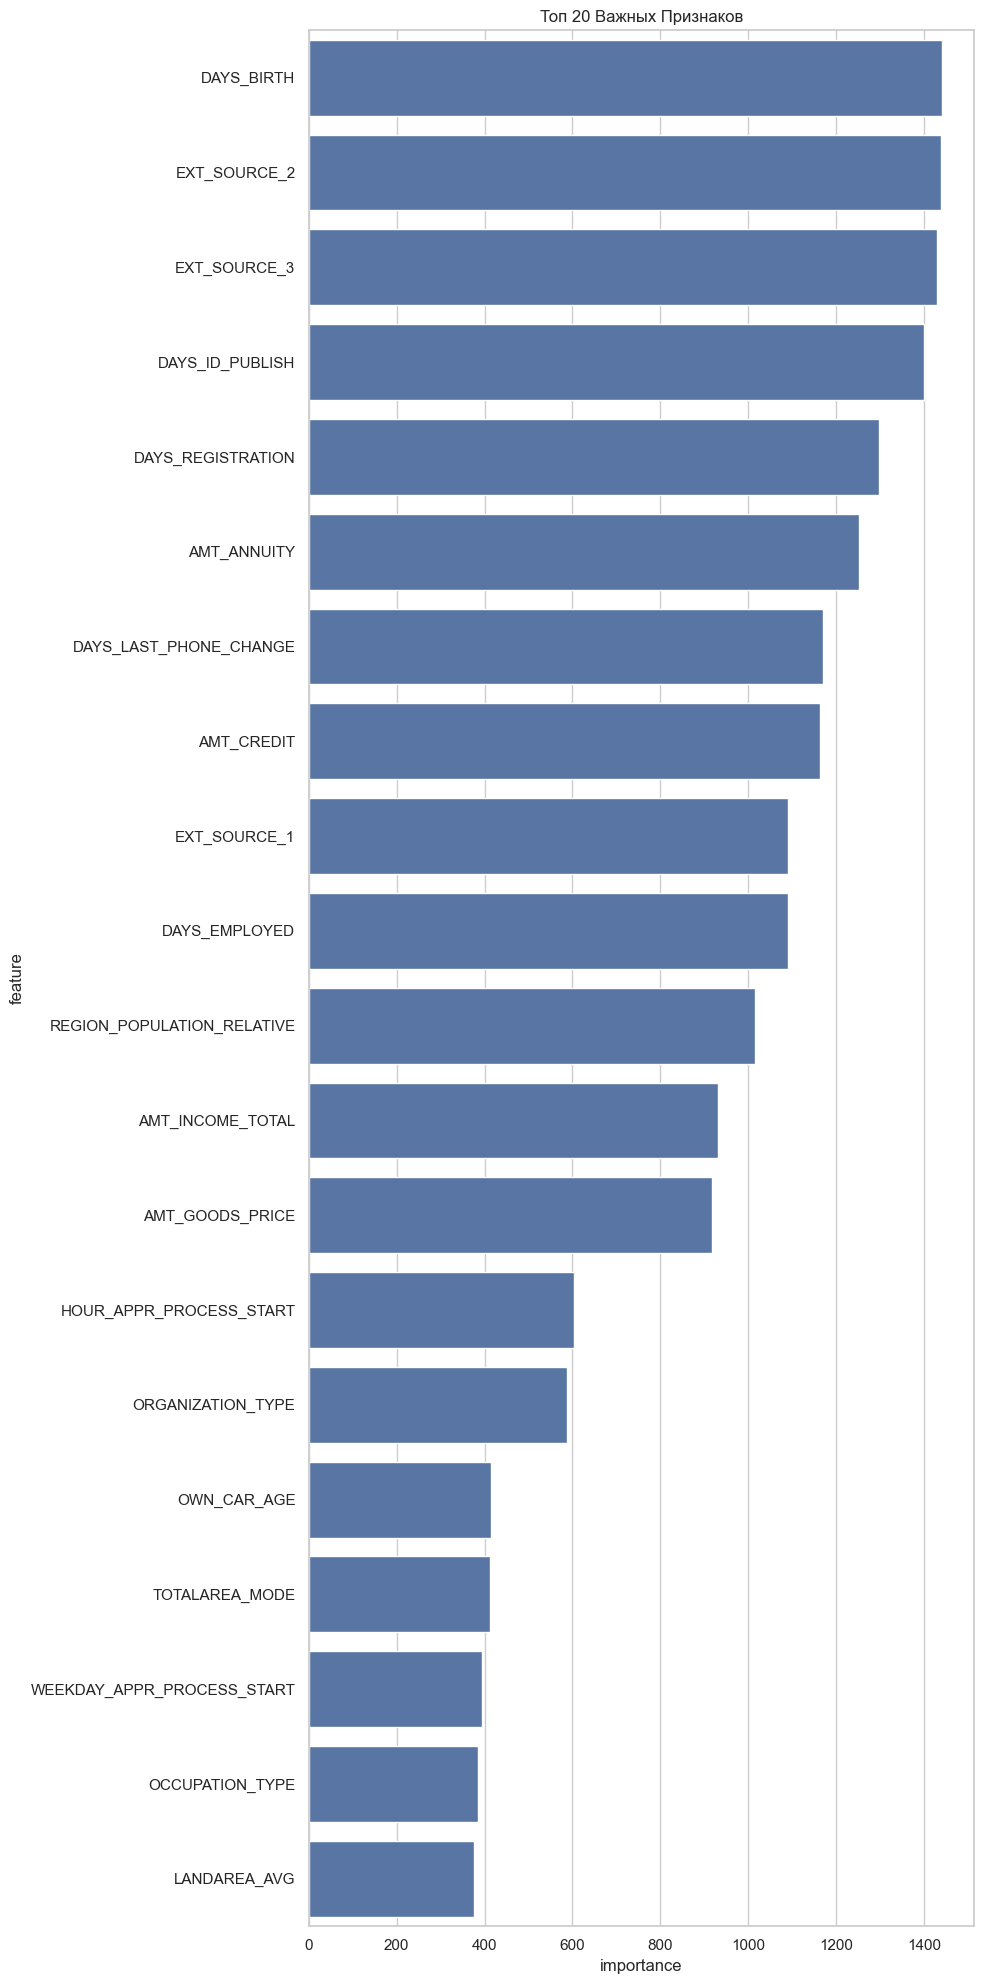

In [16]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import os

# Для моделирования
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Бустинговый классификатор LightGBM
import lightgbm as lgb

# Для обработки категориальных переменных
from sklearn.preprocessing import LabelEncoder

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='whitegrid')


filepath = "C:\\Users\\александр\\PycharmProjects\\RecSys\\datasets\\home-credit-default-risk\\application_train.csv"

# Загрузка данных
df_train = pd.read_csv(filepath)



print("\nКоличество пропусков в каждом столбце:")
missing_values = df_train.isnull().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])


numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()
numeric_features.remove('TARGET')
numeric_features.remove('SK_ID_CURR') if 'SK_ID_CURR' in numeric_features else None
categorical_features.remove('SK_ID_CURR') if 'SK_ID_CURR' in categorical_features else None

for col in numeric_features:
    df_train[col].fillna(df_train[col].median(), inplace=True)
for col in categorical_features:
    df_train[col].fillna(df_train[col].mode()[0], inplace=True)


print("\nОбщее количество оставшихся пропусков:", df_train.isnull().sum().sum())

le = LabelEncoder()
for col in categorical_features:
    df_train[col] = le.fit_transform(df_train[col])

print("\nДанные после кодирования категориальных признаков:")
print(df_train.head())

X = df_train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_train['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Параметры модели
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

model = lgb.train(params,
    train_data,
    valid_sets=[train_data, val_data],
    num_boost_round=1000)
# Предсказания на валидационной выборке
y_pred = model.predict(X_val, num_iteration=model.best_iteration)

# Расчет AUC ROC
auc = roc_auc_score(y_val, y_pred)
print(f"\nAUC ROC на валидационной выборке: {auc:.4f}")

# Визуализация важности признаков
importances = model.feature_importance()
feature_names = X_train.columns
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Построение графика важности признаков
plt.figure(figsize=(10, 20))
sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
plt.title('Топ 20 Важных Признаков')
plt.tight_layout()
plt.show()


C:\Users\александр\AppData\Local\Temp\ipykernel_14260\872185429.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df_train, palette='viridis')


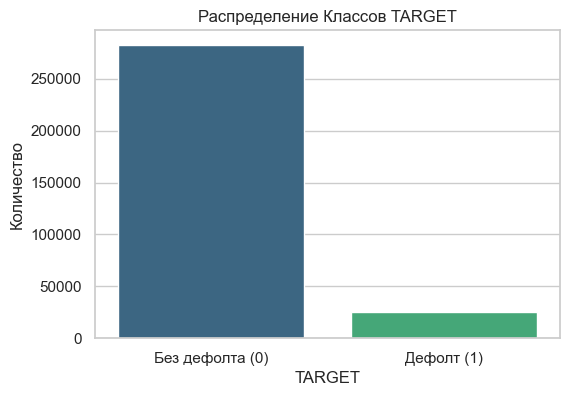

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стиля графиков
sns.set(style='whitegrid')

# Предполагается, что df_train уже загружен
# Если нет, загрузите данные следующим образом:
# filepath = "C:\\Users\\александр\\PycharmProjects\\RecSys\\datasets\\home-credit-default-risk\\application_train.csv"
# df_train = pd.read_csv(filepath)

# Гистограмма распределения классов TARGET
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df_train, palette='viridis')
plt.title('Распределение Классов TARGET')
plt.xlabel('TARGET')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Без дефолта (0)', 'Дефолт (1)'])
plt.show()


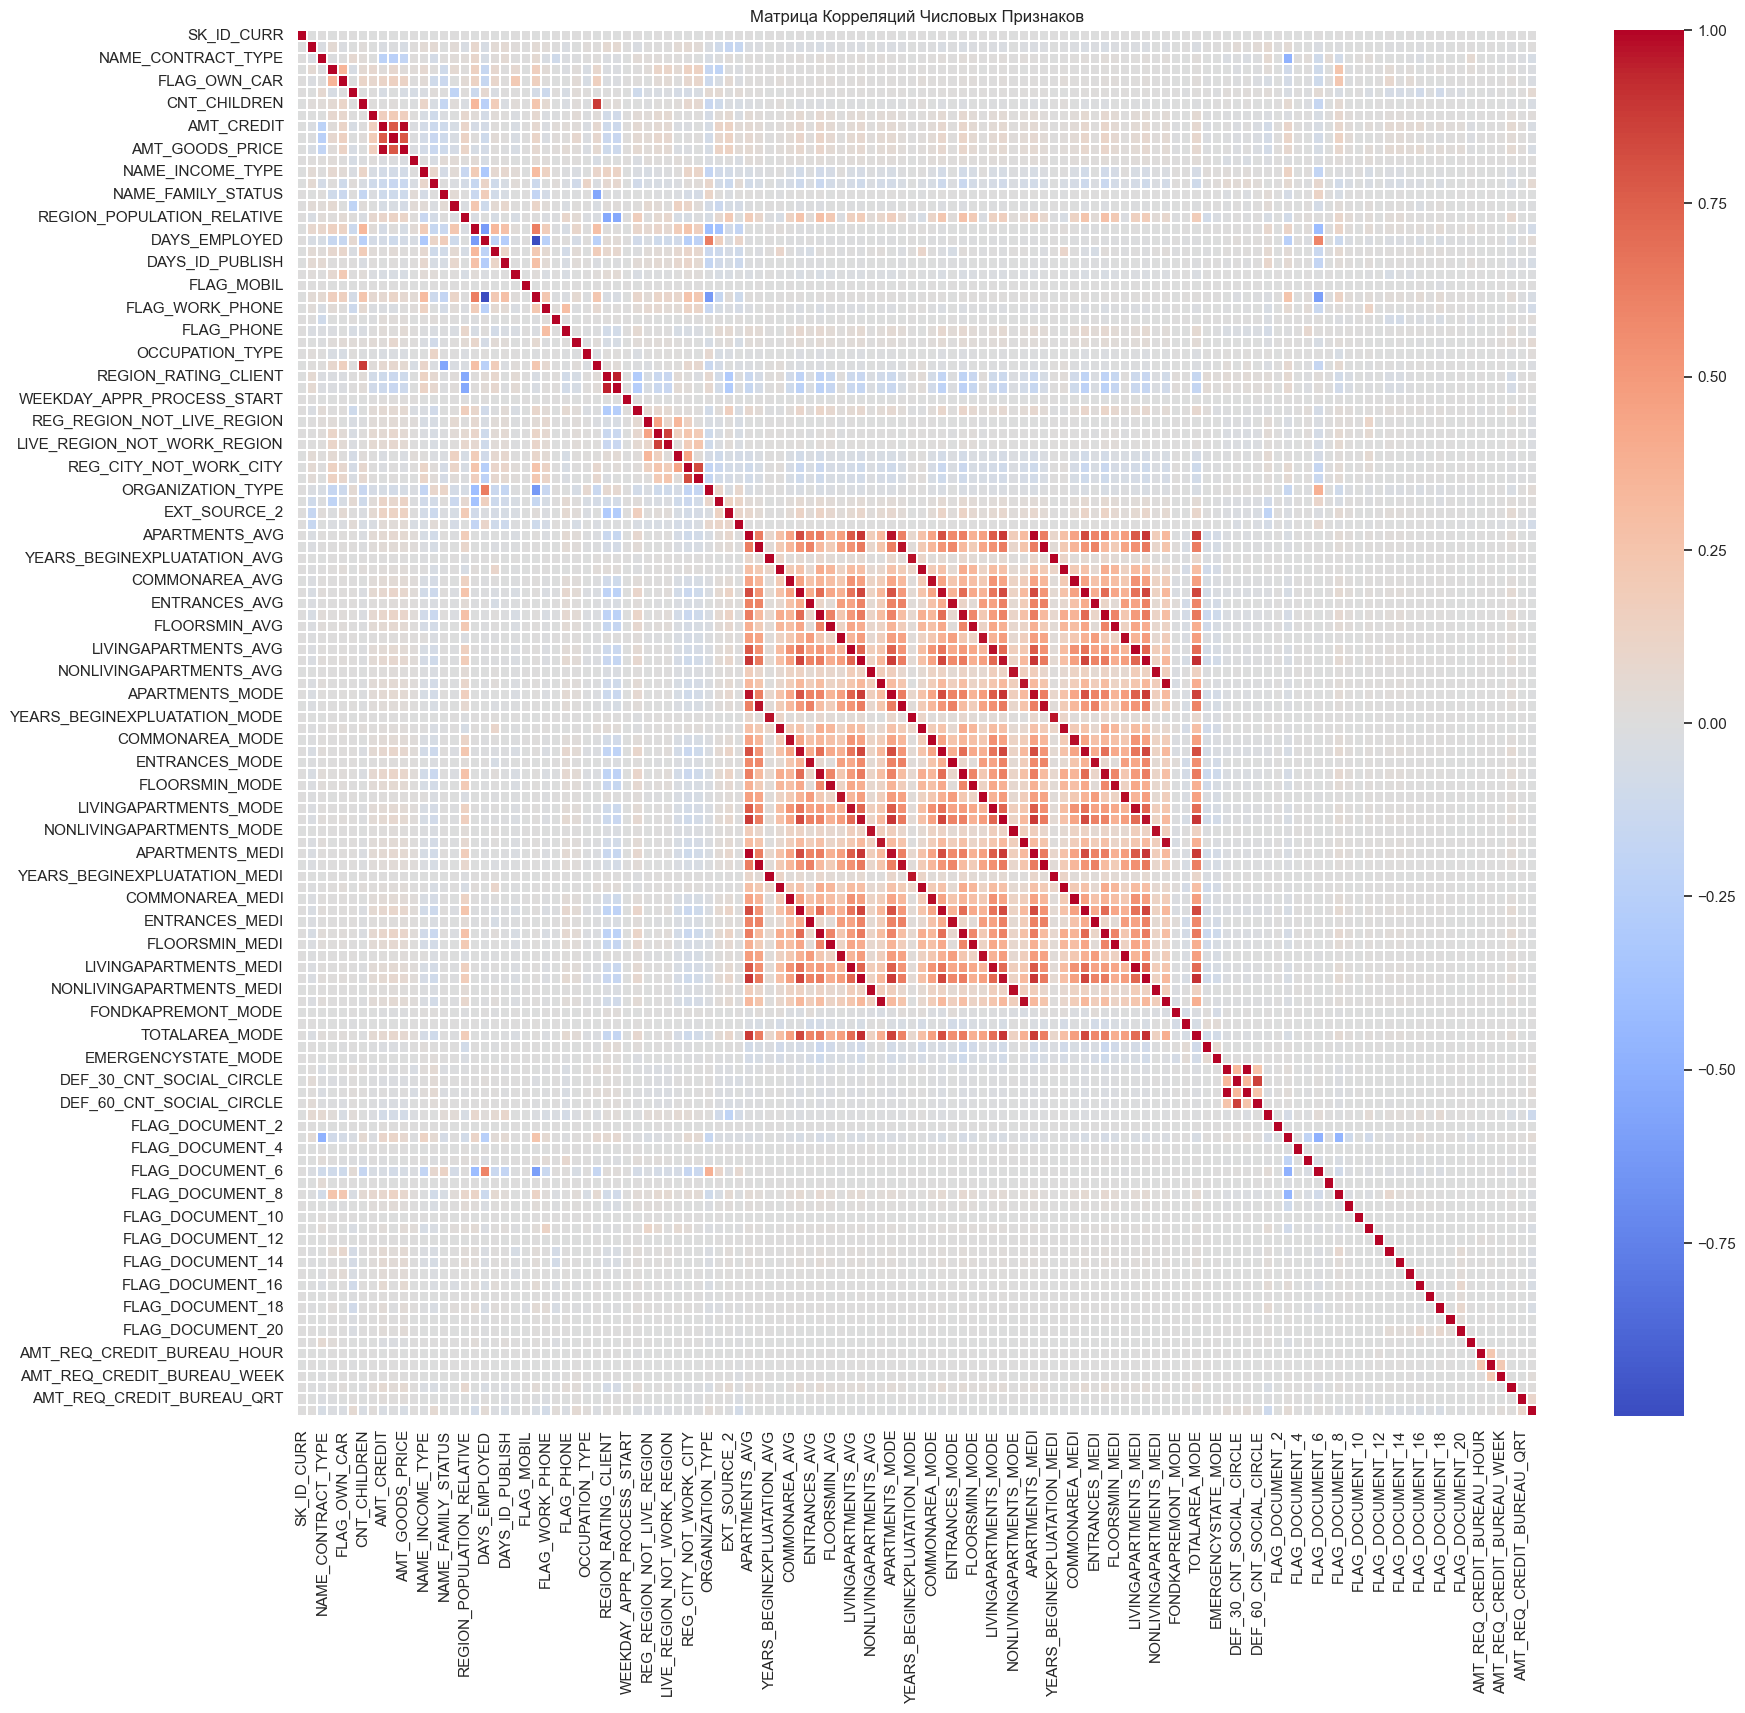

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стиля графиков
sns.set(style='white')

# Выбор числовых признаков для корреляции
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()

# Вычисление матрицы корреляций
corr_matrix = df_train[numeric_features].corr()

# Размер графика (можно увеличить для больших матриц)
plt.figure(figsize=(20, 18))

# Построение тепловой карты корреляций с аннотацией коэффициентов
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', linewidths=0.1)

plt.title('Матрица Корреляций Числовых Признаков')
plt.show()


In [30]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

model = lgb.train(params,
    train_data,
    valid_sets=[train_data, val_data],
    num_boost_round=10000,
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(50)])

Training until validation scores don't improve for 100 rounds
[50]	training's auc: 0.757936	valid_1's auc: 0.74871
[100]	training's auc: 0.774822	valid_1's auc: 0.756007
[150]	training's auc: 0.787793	valid_1's auc: 0.758072
[200]	training's auc: 0.799372	valid_1's auc: 0.759108
[250]	training's auc: 0.809249	valid_1's auc: 0.75939
[300]	training's auc: 0.818653	valid_1's auc: 0.76019
[350]	training's auc: 0.826906	valid_1's auc: 0.76069
[400]	training's auc: 0.835298	valid_1's auc: 0.761036
[450]	training's auc: 0.842719	valid_1's auc: 0.761316
[500]	training's auc: 0.849788	valid_1's auc: 0.761377
[550]	training's auc: 0.856269	valid_1's auc: 0.761341
Early stopping, best iteration is:
[480]	training's auc: 0.847016	valid_1's auc: 0.761503


In [ ]:
filepath_train = "C:\\Users\александр\PycharmProjects\RecSys\datasets\home-credit-default-risk\\application_test.csv"

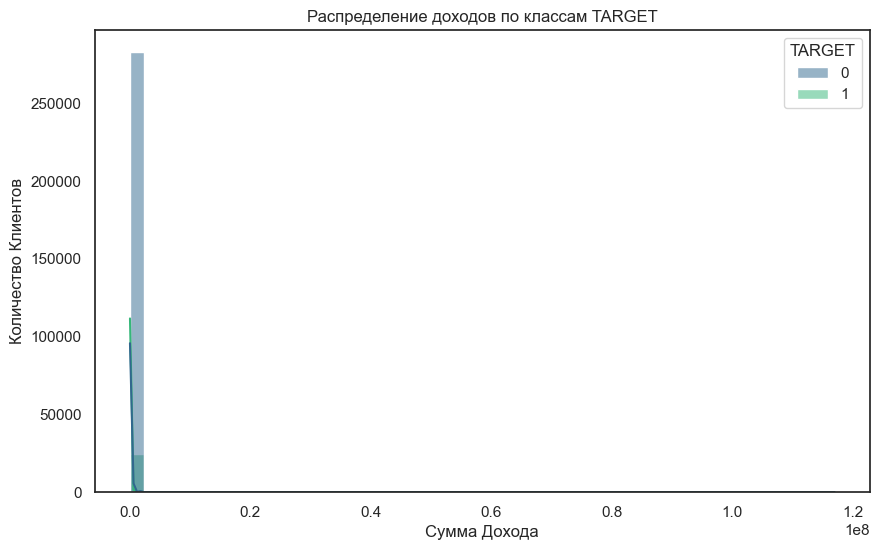

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_train, x='AMT_INCOME_TOTAL', hue='TARGET', bins=50, kde=True, palette='viridis')
plt.title('Распределение доходов по классам TARGET')
plt.xlabel('Сумма Дохода')
plt.ylabel('Количество Клиентов')
plt.show()


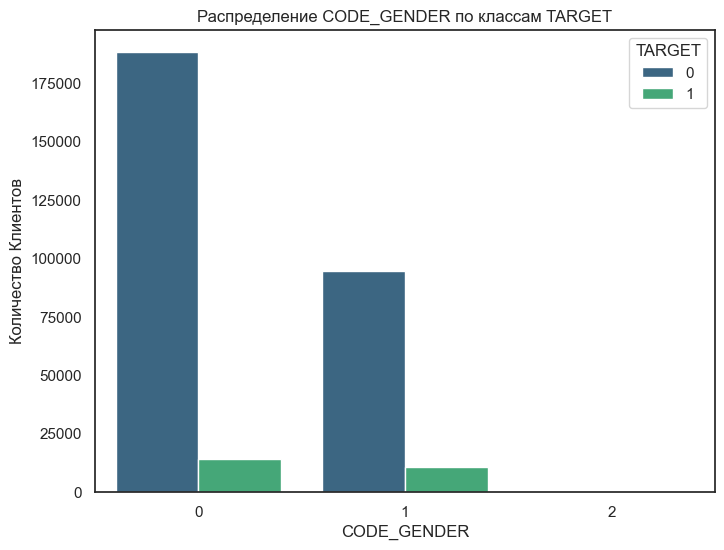

In [34]:
plt.figure(figsize=(8, 6))
sns.countplot(x='CODE_GENDER', hue='TARGET', data=df_train, palette='viridis')
plt.title('Распределение CODE_GENDER по классам TARGET')
plt.xlabel('CODE_GENDER')
plt.ylabel('Количество Клиентов')
plt.show()


In [36]:
from sklearn.model_selection import StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
auc_scores = []

# Обучение модели на каждом фолде
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\nФолд {fold + 1}/{n_splits}')
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    model_main= lgb.train(
        params,
        train_data,
        valid_sets=[train_data, val_data],
        num_boost_round=10000,
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(50)]
    )
    
    y_pred = model_main.predict(X_val, num_iteration=model_main.best_iteration)
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)
    print(f'AUC ROC на фолде {fold + 1}: {auc:.4f}')

# Итоговые результаты
print(f'\nСреднее AUC ROC по всем фолдам: {np.mean(auc_scores):.4f}')
print(f'Стандартное отклонение AUC ROC: {np.std(auc_scores):.4f}')


Фолд 1/5
Training until validation scores don't improve for 100 rounds
[50]	training's auc: 0.758891	valid_1's auc: 0.74571
[100]	training's auc: 0.775571	valid_1's auc: 0.752292
[150]	training's auc: 0.78852	valid_1's auc: 0.75444
[200]	training's auc: 0.799877	valid_1's auc: 0.755451
[250]	training's auc: 0.809717	valid_1's auc: 0.75574
[300]	training's auc: 0.818826	valid_1's auc: 0.755981
[350]	training's auc: 0.82692	valid_1's auc: 0.75564
Early stopping, best iteration is:
[288]	training's auc: 0.816652	valid_1's auc: 0.756149
AUC ROC на фолде 1: 0.7561

Фолд 2/5
Training until validation scores don't improve for 100 rounds
[50]	training's auc: 0.755462	valid_1's auc: 0.751077
[100]	training's auc: 0.773196	valid_1's auc: 0.759535
[150]	training's auc: 0.786598	valid_1's auc: 0.761985
[200]	training's auc: 0.797785	valid_1's auc: 0.762963
[250]	training's auc: 0.808049	valid_1's auc: 0.763668
[300]	training's auc: 0.81733	valid_1's auc: 0.764016
[350]	training's auc: 0.825703	va

In [37]:
import joblib

# Сохранение обученной модели
joblib.dump(model_main, 'lgbm_model.joblib')
print("Модель сохранена в файл 'lgbm_model.joblib'")


Модель сохранена в файл 'lgbm_model.joblib'


In [38]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Загрузка сохранённой модели
model = joblib.load('lgbm_model.joblib')
print("Модель загружена успешно.")

# Путь к тестовому набору данных
test_filepath = "C:\\Users\\александр\\PycharmProjects\\RecSys\\datasets\\home-credit-default-risk\\application_test.csv"

# Загрузка тестовых данных
df_test = pd.read_csv(test_filepath)
print("Тестовые данные загружены успешно.")


Модель загружена успешно.
Тестовые данные загружены успешно.


In [39]:
combined = pd.concat([X, df_test.drop(['SK_ID_CURR'], axis=1)], axis=0)

# Идентификация категориальных признаков
categorical_features = combined.select_dtypes(include=['object']).columns.tolist()

# Инициализация и обучение LabelEncoder для каждого категориального признака
le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    # Заполнение пропусков перед кодированием
    combined[col] = combined[col].fillna('Unknown')
    combined[col] = le.fit_transform(combined[col].astype(str))
    le_dict[col] = le

# Разделение обратно на обучающие и тестовые данные
X_test = combined.iloc[len(X):, :].copy()
print("Предобработка тестовых данных завершена.")   

Предобработка тестовых данных завершена.


In [48]:
# Предсказание вероятностей дефолта
y_test_pred_proba = model_main.predict(X_test)

# Создание DataFrame с предсказаниями
submission_test = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET': y_test_pred_proba
})
print("Предсказания сформированы.")

Предсказания сформированы.


In [49]:
# Сохранение предсказаний в CSV файл
submission_test.to_csv('C:\\Users\александр\PycharmProjects\RecSys\datasets\\test_pred.csv', index=False)
print("Предсказания сохранены в файл 'test_predictions.csv'")

Предсказания сохранены в файл 'test_predictions.csv'


In [1]:
import pandas as pd
import numpy as np

# Шаг 1: Загрузка Данных
application_train_path = "C:/Users/александр/PycharmProjects/RecSys/datasets/home-credit-default-risk/application_train.csv"
bureau_path = "C:/Users/александр/PycharmProjects/RecSys/datasets/home-credit-default-risk/bureau.csv"

df_application = pd.read_csv(application_train_path)
df_bureau = pd.read_csv(bureau_path)

# Шаг 2: Исследование Структуры Данных
print("Количество уникальных SK_ID_CURR в application_train:", df_application['SK_ID_CURR'].nunique())
print("Количество уникальных SK_ID_CURR в bureau:", df_bureau['SK_ID_CURR'].nunique())

# Шаг 3: Агрегация Данных из bureau.csv
# Выберем ключевые признаки для агрегации. Это могут быть числовые признаки, которые будут агрегированы.
# Пример: 'DAYS_CREDIT', 'AMT_CREDIT', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE'

# Определение функций агрегации для каждого признака
agg_functions = {
    'DAYS_CREDIT': ['min', 'max', 'mean', 'median'],
    'AMT_CREDIT': ['sum', 'mean', 'median', 'max'],
    'CREDIT_ACTIVE': ['nunique', 'count'],
    'CREDIT_CURRENCY': ['nunique', 'count'],
    'CREDIT_TYPE': ['nunique', 'count']
}

# Применение агрегации
bureau_agg = df_bureau.groupby('SK_ID_CURR').agg(agg_functions)

# Разворачивание MultiIndex колонок в одном уровне
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg.reset_index(inplace=True)

print("\nАгрегированные данные из bureau.csv:")
print(bureau_agg.head())

# Шаг 4: Объединение Датасетов
# Объединяем application_train с агрегированными данными из bureau
df_merged = df_application.merge(bureau_agg, on='SK_ID_CURR', how='left')

print("\nОбъединённые данные:")
print(df_merged.head())

# Шаг 5: Обработка Пропусков После Объединения
# Проверим количество пропусков
print("\nКоличество пропусков после объединения:")
print(df_merged.isnull().sum())

# Заполнение пропусков для агрегированных признаков
# Для признаков, связанных с количеством или уникальностью, заполним пропуски нулями
count_unique_features = ['CREDIT_ACTIVE_nunique', 'CREDIT_CURRENCY_nunique', 'CREDIT_TYPE_nunique',
                        'CREDIT_ACTIVE_count', 'CREDIT_CURRENCY_count', 'CREDIT_TYPE_count']

for col in count_unique_features:
    df_merged[col].fillna(0, inplace=True)

# Для числовых признаков заполним пропуски медианой или средним значением
numeric_features = ['DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_mean', 'DAYS_CREDIT_median',
                    'AMT_CREDIT_sum', 'AMT_CREDIT_mean', 'AMT_CREDIT_median', 'AMT_CREDIT_max']

for col in numeric_features:
    df_merged[col].fillna(df_merged[col].median(), inplace=True)

# Проверка, что пропуски заполнены
print("\nКоличество пропусков после заполнения:")
print(df_merged.isnull().sum())

# Шаг 6: Проверка и Очистка Данных
# Опционально: удалить столбцы, которые могут быть избыточными или имеют слишком высокую корреляцию с другими
# Например, если 'CREDIT_ACTIVE_count' слишком сильно коррелирует с 'AMT_CREDIT_sum', можно рассмотреть удаление одного из них

# Пример удаления признака
# df_merged.drop(['CREDIT_ACTIVE_count'], axis=1, inplace=True)

df_merged.to_csv('application_train_merged.csv', index=False)
print("Объединённые данные сохранены в 'application_train_merged.csv'")


Количество уникальных SK_ID_CURR в application_train: 307511
Количество уникальных SK_ID_CURR в bureau: 305811


KeyError: "Column(s) ['AMT_CREDIT'] do not exist"

In [3]:
import pandas as pd
import numpy as np

# Шаг 1: Загрузка Данных
application_train_path = "C:/Users/александр/PycharmProjects/RecSys/datasets/home-credit-default-risk/application_train.csv"
bureau_path = "C:/Users/александр/PycharmProjects/RecSys/datasets/home-credit-default-risk/bureau.csv"

df_application = pd.read_csv(application_train_path)
df_bureau = pd.read_csv(bureau_path)

# Шаг 2: Проверка Наличия Колонки AMT_CREDIT
if 'AMT_CREDIT' not in df_bureau.columns:
    print("Колонка 'AMT_CREDIT' отсутствует в bureau.csv")
    # Допустим, колонка называется 'Amt_Credit', переименуем её
    if 'Amt_Credit' in df_bureau.columns:
        df_bureau.rename(columns={'Amt_Credit': 'AMT_CREDIT'}, inplace=True)
        print("Колонка 'Amt_Credit' переименована в 'AMT_CREDIT'")
    else:
        print("Не удалось найти колонку 'AMT_CREDIT' или её вариант.")
        # Если колонка действительно отсутствует, рассмотрите удаление её из агрегации
        # или использование другой релевантной колонки

# Проверка после возможного переименования
if 'AMT_CREDIT' in df_bureau.columns:
    print("Колонка 'AMT_CREDIT' найдена.")
else:
    print("Колонка 'AMT_CREDIT' всё ещё отсутствует. Проверьте данные.")

# Шаг 3: Агрегация Данных из bureau.csv
if 'AMT_CREDIT' in df_bureau.columns:
    agg_functions = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'median'],
        'AMT_CREDIT': ['sum', 'mean', 'median', 'max'],
        'CREDIT_ACTIVE': ['nunique', 'count'],
        'CREDIT_CURRENCY': ['nunique', 'count'],
        'CREDIT_TYPE': ['nunique', 'count']
    }

    # Применение агрегации
    bureau_agg = df_bureau.groupby('SK_ID_CURR').agg(agg_functions)

    # Разворачивание MultiIndex колонок в одном уровне
    bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
    bureau_agg.reset_index(inplace=True)

    print("\nАгрегированные данные из bureau.csv:")
    print(bureau_agg.head())
else:
    # Если 'AMT_CREDIT' отсутствует, пропустим агрегацию этого признака
    agg_functions = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'median'],
        # 'AMT_CREDIT': ['sum', 'mean', 'median', 'max'],  # Закомментируем или удалим
        'CREDIT_ACTIVE': ['nunique', 'count'],
        'CREDIT_CURRENCY': ['nunique', 'count'],
        'CREDIT_TYPE': ['nunique', 'count']
    }

    bureau_agg = df_bureau.groupby('SK_ID_CURR').agg(agg_functions)
    bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
    bureau_agg.reset_index(inplace=True)

    print("\nАгрегированные данные из bureau.csv без 'AMT_CREDIT':")
    print(bureau_agg.head())

# Шаг 4: Объединение Датасетов
df_merged = df_application.merge(bureau_agg, on='SK_ID_CURR', how='left')

print("\nОбъединённые данные:")
print(df_merged.head())

# Шаг 5: Обработка Пропусков После Объединения
print("\nКоличество пропусков после объединения:")
print(df_merged.isnull().sum())

# Заполнение пропусков для агрегированных признаков
count_unique_features = ['CREDIT_ACTIVE_nunique', 'CREDIT_CURRENCY_nunique', 'CREDIT_TYPE_nunique',
                        'CREDIT_ACTIVE_count', 'CREDIT_CURRENCY_count', 'CREDIT_TYPE_count']

for col in count_unique_features:
    if col in df_merged.columns:
        df_merged[col].fillna(0, inplace=True)

# Заполнение пропусков для числовых признаков медианой
numeric_features = ['DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_mean', 'DAYS_CREDIT_median',
                    'AMT_CREDIT_sum', 'AMT_CREDIT_mean', 'AMT_CREDIT_median', 'AMT_CREDIT_max']

for col in numeric_features:
    if col in df_merged.columns:
        df_merged[col].fillna(df_merged[col].median(), inplace=True)

# Проверка, что пропуски заполнены
print("\nКоличество пропусков после заполнения:")
print(df_merged.isnull().sum())
df_merged.to_csv("merged_data.csv",index=False)


Колонка 'AMT_CREDIT' отсутствует в bureau.csv
Не удалось найти колонку 'AMT_CREDIT' или её вариант.
Колонка 'AMT_CREDIT' всё ещё отсутствует. Проверьте данные.

Агрегированные данные из bureau.csv без 'AMT_CREDIT':
   SK_ID_CURR  DAYS_CREDIT_min  DAYS_CREDIT_max  DAYS_CREDIT_mean  \
0      100001            -1572              -49       -735.000000   
1      100002            -1437             -103       -874.000000   
2      100003            -2586             -606      -1400.750000   
3      100004            -1326             -408       -867.000000   
4      100005             -373              -62       -190.666667   

   DAYS_CREDIT_median  CREDIT_ACTIVE_nunique  CREDIT_ACTIVE_count  \
0              -857.0                      2                    7   
1             -1042.5                      2                    8   
2             -1205.5                      2                    4   
3              -867.0                      1                    2   
4              -137.0    

C:\Users\александр\AppData\Local\Temp\ipykernel_15164\3767718529.py:81: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged[col].fillna(0, inplace=True)
C:\Users\александр\AppData\Local\Temp\ipykernel_15164\3767718529.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [9]:
merged_data = pd.read_csv("merged_data.csv")
print(merged_data.shape)
print(df_application.shape)

(307511, 132)
(307511, 122)


In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score
filepath_rf = "application_train_prepared.csv"
df_train = pd.read_csv(filepath_rf)
X = df_train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_train['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_rf = RandomForestClassifier(verbose=1,n_jobs=-1)
model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_val)
auc = roc_auc_score(y_pred_rf,y_val)
print(auc)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   30.8s finished
[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.1s


0.7096906663197099


[Parallel(n_jobs=6)]: Done 100 out of 100 | elapsed:    0.5s finished


In [9]:
import xgboost as xgb
import pandas as pd
import joblib
import sklearn as skl
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
model_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss',verbosity=1, n_jobs=-1,)
print("Обучение XGBoost...")
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_val)
auc = roc_auc_score(y_pred_xgb,y_val)
print(auc)


Обучение XGBoost...
0.711550142565439
